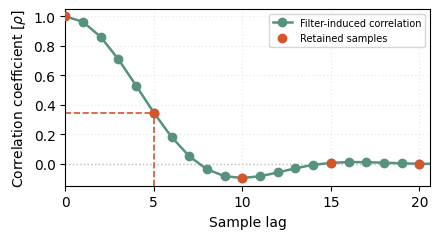

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_coeffs
import cmasher as cmr


def kernel_autocorrelation(kernel: np.ndarray):
    """Normalized autocorrelation of a filter kernel."""
    corr = np.correlate(kernel, kernel, mode="full")
    corr /= corr[corr.size // 2]

    lags = np.arange(-(kernel.size - 1), kernel.size)
    return lags, corr

h11 = savgol_coeffs(
    window_length=11,
    polyorder=2,
    use="conv",
)

h15 = savgol_coeffs(
    window_length=15,
    polyorder=2,
    use="conv",
)

# Sequential filtering
h = np.convolve(h11, h15)

lags, rho = kernel_autocorrelation(h)

# Keep only positive lags
mask = lags >= 0
lags = lags[mask]
rho = rho[mask]

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

decimation = 5

fig, ax = plt.subplots(figsize=(4.5, 2.5))

ax.plot(
    lags,
    rho,
    "-o",
    color=cmr.pride([0.3]),
    lw=1.8,
    label="Filter-induced correlation",
)

# Highlight retained samples
sample_lags = np.arange(0, lags.max() + 1, decimation)

ax.scatter(
    sample_lags,
    rho[sample_lags],
    s=36,
    color=cmr.pride([0.7]),
    zorder=5,
    label="Retained samples",
)

# Mark the first retained neighbour
ax.axvline(
    x=decimation,
    ymax=rho[decimation]+0.1,
    color=cmr.pride([0.7]),
    ls="--",
    lw=1.2,
)

ax.axhline(
    y=rho[decimation],
    xmax=(decimation+1)/lags.max(),
    color=cmr.pride([0.7]),
    ls="--",
    lw=1.2,
)

# ax.annotate(
#     f"$\\rho={rho[decimation]:.2f}$",
#     xy=(decimation, rho[decimation]),
#     xytext=(6.4, 0.6),
#     arrowprops=dict(arrowstyle="->", lw=1),
# )

ax.set_xlim(0, 20.6)
ax.set_ylim(-0.15, 1.05)

ax.set_xlabel("Sample lag")
ax.set_ylabel(r"Correlation coefficient [$\rho$]")

ax.grid(
    color="#cccccc",
    alpha=0.36,
    lw=1,
    ls=":",
)

ax.axhline(0, lw=1, ls=":", color="#222", alpha=0.3, zorder=-1)
# ax.legend(frameon=False)

ax.legend(
    loc="upper right",
    fontsize=7,
)

fig.tight_layout()
plt.savefig(f"../data/plots/savgol_correlation.pdf", bbox_inches="tight", pad_inches=0.03,)